# Medical Pathology QA — LoRA fine-tuning of Llama-3.2-1B
*Ablation study. Metric = Kaggle competition test accuracy (public == private).*

**Result: 0.7700 → 0.7988** via LoRA rank + training recipe + a cross-strategy ensemble.
Code: [`src/`](src/) · experiments + journal: [`experiments/NOTES.md`](experiments/NOTES.md).

## Code organisation — config-driven (same code, different config)
`run.sbatch` → `accelerate launch main.py --base configs/base.yaml --config <cell>/config.yaml`

| File | Role |
|---|---|
| [`configs/base.yaml`](configs/base.yaml) | defaults: LoRA `r`/`alpha`/targets, training `lr`/batch/epochs, prompts |
| [`main.py`](main.py) | deep-merge config → build → train → benchmark inference |
| [`src/model.py`](src/model.py) | wrap base with LoRA (`get_peft_model`) |
| [`src/data.py`](src/data.py) | `format_prompt` (zero/few-shot/CoT) + dataset |
| [`src/train.py`](src/train.py) | training loop (accelerate DDP, save-best-by-val) |
| [`src/evaluate.py`](src/evaluate.py) | inference → submission CSV |

Each ablation = one frozen cell in [`experiments/`](experiments/): `config.yaml` (the knob) + `run.sbatch`.

In [1]:
%matplotlib inline
import json, os, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": .3})

# All Kaggle TEST scores below are real recorded results from our runs
# (public == private on this competition). See experiments/NOTES.md.
RANK = {8:0.7100, 16:0.7277, 32:0.7444, 64:0.7611, 128:0.7666,   # exp01
        192:0.7700, 256:0.7766, 384:0.7577, 512:0.7533}          # exp02
RANK_PROXY = {8:0.6970,16:0.7266,32:0.7457,64:0.7422,128:0.7370, # exp01 val proxy
              192:0.7405,256:0.7465,384:0.7474,512:0.7370}       # exp02 val proxy
EFFBATCH = {768:0.7766, 384:0.7666, 192:0.7844, 96:0.7488}       # exp06 (steps lever)
DORA = {"r128":(0.7666,0.7577),"r192":(0.7700,0.7566),"r256":(0.7766,0.7811)}  # (vanilla,DoRA)
PROGRESSION = [("baseline",0.7700),("exp02\nrank=256",0.7766),("exp03\nzs ensemble",0.7811),
               ("exp04\n+few_shot",0.7888),("exp07\n@eff192",0.7922),("exp08\nmulti-shot",0.7988)]
print("Loaded recorded Kaggle test scores for ablations.")

Loaded recorded Kaggle test scores for ablations.


## 1. Problem & data

9k labelled pathology MCQs ([`dataset/dataset.csv`](dataset/dataset.csv)); 900
unlabelled test questions ([`dataset/benchmark.csv`](dataset/benchmark.csv)).
Each example = a question + 4 options (A–D) + the gold letter.

labelled examples: 9000   columns: ['question_id', 'question', 'opa', 'opb', 'opc', 'opd', 'ans']

Q: RBC contains?
 A. Iron
 B. Folic acid
 C. Vitamin C
 D. Biotin
 gold: A


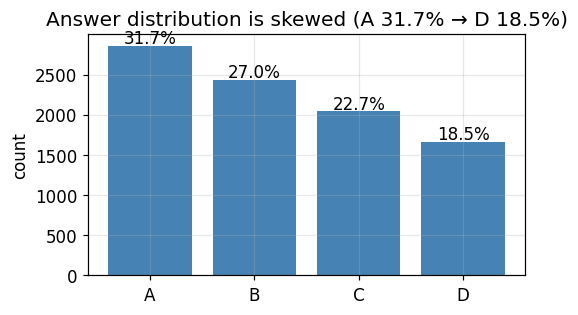

Note: per-gold recall is balanced (A .78 / B .73 / C .71 / D .71) — the model
matches this real skew; it is NOT a label bias to 'fix'.


In [2]:
df = pd.read_csv("dataset/dataset.csv")
print(f"labelled examples: {len(df)}   columns: {list(df.columns)}")
ex = df.iloc[0]
print(f"\nQ: {ex['question']}\n A. {ex['opa']}\n B. {ex['opb']}\n C. {ex['opc']}\n D. {ex['opd']}\n gold: {'ABCD'[int(ex['ans'])]}")

dist = df['ans'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['A','B','C','D'], dist.values, color='steelblue')
for i,v in enumerate(dist.values): ax.text(i, v+30, f"{v/len(df)*100:.1f}%", ha='center')
ax.set_title("Answer distribution is skewed (A 31.7% → D 18.5%)"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()
print("Note: per-gold recall is balanced (A .78 / B .73 / C .71 / D .71) — the model\nmatches this real skew; it is NOT a label bias to 'fix'.")

## Methods (5)

| Method | Varies | Code | Ablation |
|---|---|---|---|
| **A. LoRA** | rank (capacity) | [`src/model.py`](src/model.py) | rank sweep |
| **B. Recipe** | effective batch = steps | [`src/train.py`](src/train.py) | eff-batch sweep |
| **C. DoRA** | weight-decomposed LoRA | [`exp05`](experiments/exp05_dora_variant/) | DoRA vs LoRA |
| **D. Strategy** | zero- vs few-shot | [`src/data.py`](src/data.py) | in ensemble |
| **E. Ensemble** | combine adapters | [`exp04`](experiments/exp04_strategy_diverse/e04c/main.py) | progression + diversity |

### A. LoRA fine-tuning — [`src/model.py`](src/model.py)
Low-rank adapters on all 7 linear layers; key knob = **rank `r`**.
```python
lora_config = LoraConfig(task_type=TaskType.CAUSAL_LM, r=256, lora_alpha=512,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=0.05, bias="none")
model = get_peft_model(base_model, lora_config)
```
📂 knob `lora.r` in [`configs/base.yaml`](configs/base.yaml) · cells [`exp01`](experiments/exp01_lora_rank/) / [`exp02`](experiments/exp02_rank_scaling/) (e.g. [`e02c/config.yaml`](experiments/exp02_rank_scaling/e02c/config.yaml) + [`run.sbatch`](experiments/exp02_rank_scaling/e02c/run.sbatch))

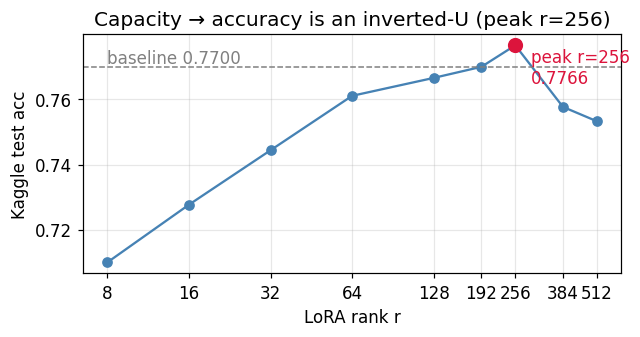

In [3]:
xs = sorted(RANK); ys = [RANK[r] for r in xs]
fig, ax = plt.subplots(figsize=(6,3.2))
ax.plot(xs, ys, 'o-', color='steelblue')
peak = max(RANK, key=RANK.get)
ax.scatter([peak],[RANK[peak]], color='crimson', zorder=5, s=80)
ax.annotate(f"peak r={peak}\n{RANK[peak]:.4f}", (peak,RANK[peak]),
            textcoords="offset points", xytext=(10,-25), color='crimson')
ax.axhline(0.7700, ls='--', color='gray', lw=1); ax.text(8,0.7710,"baseline 0.7700",color='gray')
ax.set_xscale('log', base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("Kaggle test acc")
ax.set_title("Capacity → accuracy is an inverted-U (peak r=256)")
plt.tight_layout(); plt.show()

### B. Training recipe — [`src/train.py`](src/train.py)
Effective batch = per-GPU batch × grad-accum × GPUs. Default **768** → ~110 steps (under-trained); smaller batch ⇒ more steps.
📂 knob `batch_size`/`grad_accumulation_steps` in [`exp06/e06c/config.yaml`](experiments/exp06_zeroshot_recipe/e06c/config.yaml) (eff 192); restricted-loss variant edits [`e06d/train.py`](experiments/exp06_zeroshot_recipe/e06d/train.py).

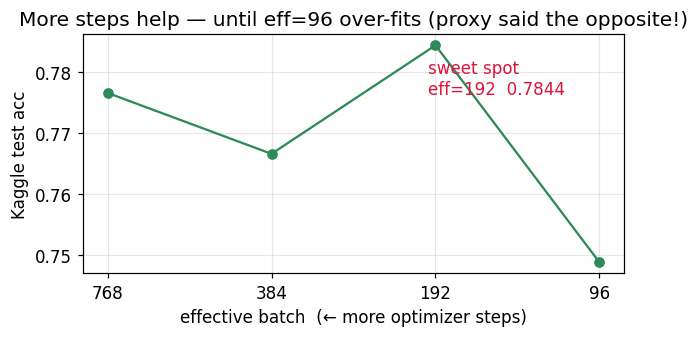

In [4]:
xs = sorted(EFFBATCH, reverse=True); ys=[EFFBATCH[x] for x in xs]
fig, ax = plt.subplots(figsize=(6,3.2))
ax.plot([str(x) for x in xs], ys, 'o-', color='seagreen')
best=max(EFFBATCH,key=EFFBATCH.get)
ax.annotate(f"sweet spot\neff={best}  {EFFBATCH[best]:.4f}", (xs.index(best),EFFBATCH[best]),
            textcoords="offset points", xytext=(-5,-32), color='crimson')
ax.set_xlabel("effective batch  (← more optimizer steps)"); ax.set_ylabel("Kaggle test acc")
ax.set_title("More steps help — until eff=96 over-fits (proxy said the opposite!)")
plt.tight_layout(); plt.show()

### C. DoRA (weight-decomposed LoRA) — [`exp05`](experiments/exp05_dora_variant/)
```python
LoraConfig(..., use_dora=True)
```
📂 edited [`exp05/e05a/model.py`](experiments/exp05_dora_variant/e05a/model.py) + [`config.yaml`](experiments/exp05_dora_variant/e05a/config.yaml) · paper: [DoRA (arXiv:2402.09353)](https://arxiv.org/abs/2402.09353)

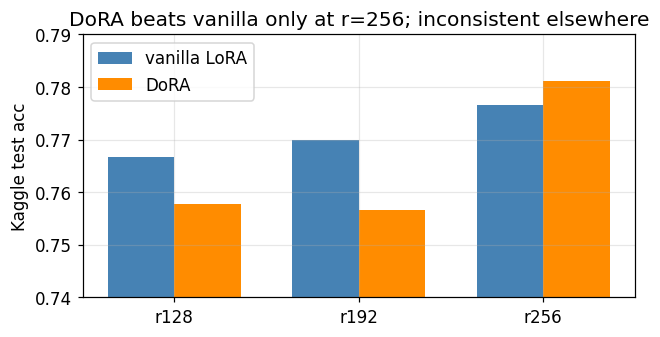

In [5]:
ranks=["r128","r192","r256"]; van=[DORA[r][0] for r in ranks]; do=[DORA[r][1] for r in ranks]
x=np.arange(len(ranks)); w=0.36
fig, ax = plt.subplots(figsize=(6,3.2))
ax.bar(x-w/2, van, w, label='vanilla LoRA', color='steelblue')
ax.bar(x+w/2, do, w, label='DoRA', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(ranks); ax.set_ylim(0.74,0.79)
ax.set_ylabel("Kaggle test acc"); ax.legend()
ax.set_title("DoRA beats vanilla only at r=256; inconsistent elsewhere")
plt.tight_layout(); plt.show()

### D. Prompt strategy — [`src/data.py`](src/data.py)
`format_prompt()`: few-shot prepends *k* in-context examples before the question (a different decision context).
📂 configs [`zero_shot`](configs/zero_shot.yaml) / [`few_shot`](configs/few_shot.yaml) / [`cot`](configs/cot.yaml) · few-shot cells [`exp07/e07b`](experiments/exp07_eff192_ensemble/e07b/config.yaml) (4-shot), [`exp08/e08a`](experiments/exp08_fewshot_diversity/e08a/config.yaml) (8), [`e08b`](experiments/exp08_fewshot_diversity/e08b/config.yaml) (2).

In [6]:
import sys, os, copy, yaml
sys.path.insert(0, os.path.abspath('.'))
from src.data import format_prompt          # the real prompt builder used in training

pcfg = yaml.safe_load(open('configs/base.yaml'))['prompting']
row = df.iloc[0]

zc = copy.deepcopy(pcfg); zc['strategy'] = 'zero_shot'
print('ZERO-SHOT PROMPT'); print('-'*64)
print(format_prompt(row, zc))

fc = copy.deepcopy(pcfg); fc['strategy'] = 'few_shot'
print('\n\nFEW-SHOT PROMPT  (2 in-context examples)'); print('-'*64)
print(format_prompt(row, fc, examples=[df.iloc[1], df.iloc[2]]))


/work/whats2000/LoRa-Llama-With-DDP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ZERO-SHOT PROMPT
----------------------------------------------------------------
You are a medical expert specializing in pathology. Answer the following multiple-choice question.

Question: RBC contains?
A. Iron
B. Folic acid
C. Vitamin C
D. Biotin
Answer with only the letter (A, B, C or D).
Answer:


FEW-SHOT PROMPT  (2 in-context examples)
----------------------------------------------------------------
You are a medical expert specializing in pathology. Answer the following multiple-choice question.

Question: Fibrosis is due to -
A. TGF-β
B. TNF -α
C. IL-7
D. IL-10
Answer: A

Question: During postmoem no tattoo is visible, but according to deceased family, there was a tattoo present. What evidence can indicate the same?
A. Lymph node
B. Surrounding subcutaneous tissue
C. Adipose tissue
D. Adjacent skin
Answer: B

Question: RBC contains?
A. Iron
B. Folic acid
C. Vitamin C
D. Biotin
Answer with only the letter (A, B, C or D).
Answer:


### E. Option-likelihood ensemble — [`exp04/e04c/main.py`](experiments/exp04_strategy_diverse/e04c/main.py)
Score the 4 answer letters by first-token log-prob; average across diverse adapters. No extra training.
```python
opt_lp = torch.log_softmax(model(**enc).logits[:, -1, :], -1)[:, opt_ids]  # 4 option log-probs
probs  = torch.softmax(opt_lp, -1)
pred   = torch.stack(per_member_probs).mean(0).argmax(-1)                  # uniform average
```
📂 best 5-member config: [`exp08/e08c/config.yaml`](experiments/exp08_fewshot_diversity/e08c/config.yaml).

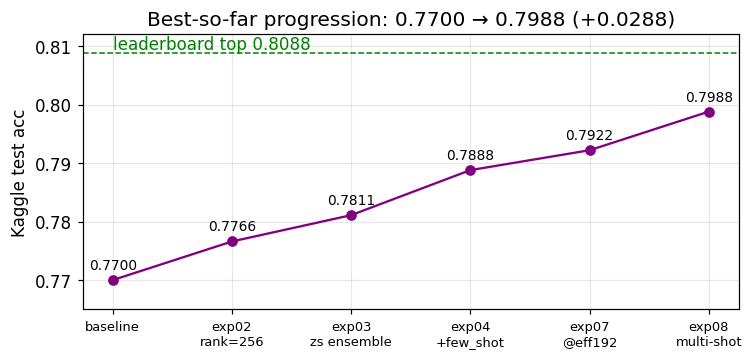

In [7]:
labels=[p[0] for p in PROGRESSION]; ys=[p[1] for p in PROGRESSION]
fig, ax = plt.subplots(figsize=(7,3.4))
ax.plot(range(len(ys)), ys, 'o-', color='purple')
for i,(l,v) in enumerate(PROGRESSION):
    ax.annotate(f"{v:.4f}", (i,v), textcoords="offset points", xytext=(0,7), ha='center', fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8.5)
ax.axhline(0.8088, ls='--', color='green', lw=1); ax.text(0,0.8095,"leaderboard top 0.8088",color='green')
ax.set_ylabel("Kaggle test acc"); ax.set_ylim(0.765,0.812)
ax.set_title("Best-so-far progression: 0.7700 → 0.7988 (+0.0288)")
plt.tight_layout(); plt.show()

## Finding 1 — validation accuracy *misranks* models
Val peaks at r=32; test rises to r=256 — **opposite directions**. ⇒ select on the real test set, not val.

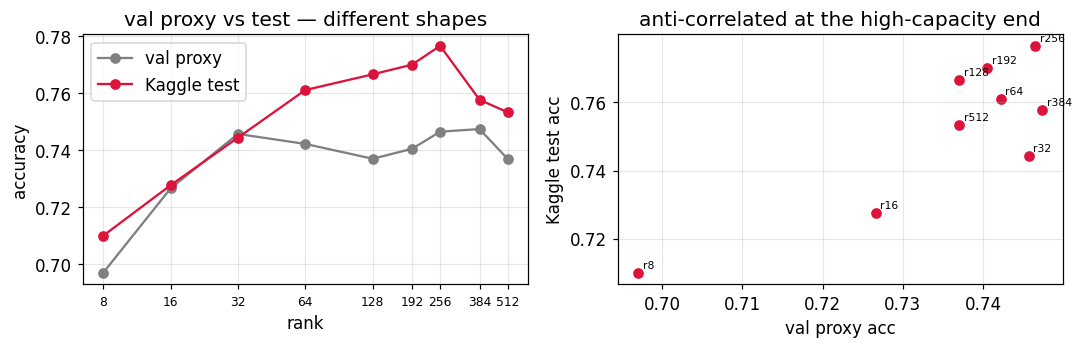

In [8]:
rs = sorted(RANK)
fig, axes = plt.subplots(1,2, figsize=(10,3.3))
axes[0].plot(rs,[RANK_PROXY[r] for r in rs],'o-',color='gray',label='val proxy')
axes[0].plot(rs,[RANK[r] for r in rs],'o-',color='crimson',label='Kaggle test')
axes[0].set_xscale('log',base=2); axes[0].set_xticks(rs); axes[0].set_xticklabels(rs,fontsize=8)
axes[0].set_xlabel("rank"); axes[0].set_ylabel("accuracy"); axes[0].legend()
axes[0].set_title("val proxy vs test — different shapes")
axes[1].scatter([RANK_PROXY[r] for r in rs],[RANK[r] for r in rs],color='crimson')
for r in rs: axes[1].annotate(f"r{r}",(RANK_PROXY[r],RANK[r]),fontsize=7,xytext=(3,3),textcoords="offset points")
axes[1].set_xlabel("val proxy acc"); axes[1].set_ylabel("Kaggle test acc")
axes[1].set_title("anti-correlated at the high-capacity end")
plt.tight_layout(); plt.show()

## Finding 2 — ensembles need *orthogonal* diversity
Lower agreement = more diverse. DoRA (same view → correlated) **hurts**; few-shot (different strategy) **helps**, even though weaker alone.

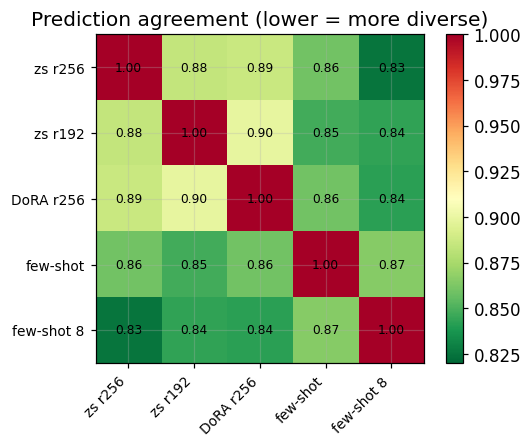

DoRA↔zs ≈ 0.89 (correlated, HURT ensemble: 0.7888→0.7855)
few-shot↔zs ≈ 0.85 (orthogonal, HELPED ensemble: 0.7811→0.7888)


In [9]:
paths = {
 'zs r256':'experiments/exp02_rank_scaling/e02c/outputs/zero_shot_submission.csv',
 'zs r192':'experiments/exp02_rank_scaling/e02b/outputs/zero_shot_submission.csv',
 'DoRA r256':'experiments/exp05_dora_variant/e05a/outputs/zero_shot_submission.csv',
 'few-shot':'experiments/exp07_eff192_ensemble/e07b/outputs/few_shot_submission.csv',
 'few-shot 8':'experiments/exp08_fewshot_diversity/e08a/outputs/few_shot_submission.csv'}
P={k:pd.read_csv(v).set_index('question_id')['pred'] for k,v in paths.items() if os.path.exists(v)}
keys=list(P); n=len(keys)
M=np.ones((n,n))
for i,a in enumerate(keys):
    for j,b in enumerate(keys): M[i,j]=(P[a]==P[b]).mean()
fig, ax = plt.subplots(figsize=(5.2,4.2))
im=ax.imshow(M, cmap='RdYlGn_r', vmin=0.82, vmax=1.0)
ax.set_xticks(range(n)); ax.set_xticklabels(keys,rotation=45,ha='right',fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(keys,fontsize=9)
for i in range(n):
    for j in range(n): ax.text(j,i,f"{M[i,j]:.2f}",ha='center',va='center',fontsize=8)
ax.set_title("Prediction agreement (lower = more diverse)")
plt.colorbar(im,fraction=0.046); plt.tight_layout(); plt.show()
print("DoRA↔zs ≈ 0.89 (correlated, HURT ensemble: 0.7888→0.7855)")
print("few-shot↔zs ≈ 0.85 (orthogonal, HELPED ensemble: 0.7811→0.7888)")

## Conclusions
**Best (0.7988):** 5-member option-LL ensemble (uniform avg), all r=256 / eff-batch 192 — `{zs, zs, fs-2, fs-4, fs-8}`.
1. Val accuracy misranks → decide on the real test.
2. Ensembles need *orthogonal* diversity (strategy / shot-count), not stronger-correlated members; saturates ~5.
3. Training recipe (eff-batch 192) matters as much as capacity.

Full numbers + root-causes: [`experiments/NOTES.md`](experiments/NOTES.md).

## Trained checkpoints
All 28 adapters: **[`whats2000/lora-llama-pathoqa-checkpoints`](https://huggingface.co/whats2000/lora-llama-pathoqa-checkpoints)** (too large for the course upload).
```python
from huggingface_hub import snapshot_download
from transformers import AutoModelForCausalLM; from peft import PeftModel; import torch
sub="experiments/exp06_zeroshot_recipe/e06c/saved_models"
loc=snapshot_download("whats2000/lora-llama-pathoqa-checkpoints", allow_patterns=f"{sub}/*")
base=AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B-Instruct", torch_dtype=torch.bfloat16)
model=PeftModel.from_pretrained(base, f"{loc}/{sub}").eval()
```